
Líquido: Agua
Ajuste lineal: eta = -1.2800e+02 * velocidad + 1.3812e+01
Coeficiente de correlación (r): -1.0000
P-valor: 0.0000
Incidencia de incertidumbre en el coeficiente de viscosidad: 0.0000e+00 Pa·s

Líquido: Aceite
Ajuste lineal: eta = -2.4918e+02 * velocidad + 1.9482e+01
Coeficiente de correlación (r): -0.9968
P-valor: 0.0002
Incidencia de incertidumbre en el coeficiente de viscosidad: 1.1507e+01 Pa·s

Líquido: Glicerina
Ajuste lineal: eta = -3.4425e+02 * velocidad + 2.2605e+01
Coeficiente de correlación (r): -0.9909
P-valor: 0.0010
Incidencia de incertidumbre en el coeficiente de viscosidad: 2.6941e+01 Pa·s


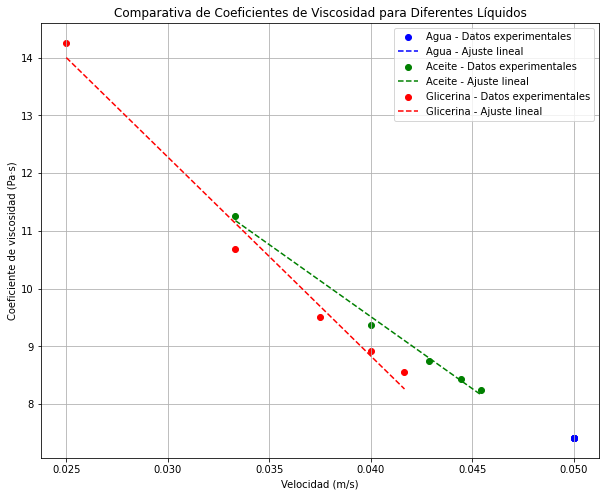

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Datos simulados para diferentes líquidos
# Supongamos tres líquidos: agua, aceite y glicerina
# Cada uno con diferentes densidades y viscosidades conocidas
liquidos = {
    "Agua": {"densidad": 1000, "viscosidad": 0.001, "color": 'blue'},
    "Aceite": {"densidad": 920, "viscosidad": 0.05, "color": 'green'},
    "Glicerina": {"densidad": 1260, "viscosidad": 1.5, "color": 'red'}
}

# Parámetros de la esfera y gravedad
radio_esfera = 0.005  # Radio de la esfera en metros
densidad_esfera = 7800  # Densidad de la esfera en kg/m³ (acero)
gravedad = 9.81  # Aceleración debido a la gravedad en m/s²

# Datos de mediciones experimentales para cada líquido
# Cada conjunto de mediciones tiene distancia (m) y tiempo (s) para cada líquido
datos_experimentales = {
    "Agua": {"distancia": np.array([0.1, 0.2, 0.3, 0.4, 0.5]),
             "tiempo": np.array([2, 4, 6, 8, 10])},
    "Aceite": {"distancia": np.array([0.1, 0.2, 0.3, 0.4, 0.5]),
               "tiempo": np.array([3, 5, 7, 9, 11])},
    "Glicerina": {"distancia": np.array([0.1, 0.2, 0.3, 0.4, 0.5]),
                  "tiempo": np.array([4, 6, 8, 10, 12])}
}

# Gráfica y cálculo de viscosidad para cada líquido
plt.figure(figsize=(10,8))

for liquido, params in liquidos.items():
    distancia = datos_experimentales[liquido]["distancia"]
    tiempo = datos_experimentales[liquido]["tiempo"]
    
    # Calcular las velocidades terminales
    velocidades = distancia / tiempo  # Velocidad en m/s
    
    # Aplicar la ley de Stokes para calcular el coeficiente de viscosidad (eta)
    coef_viscosidad = (2 * radio_esfera**2 * (densidad_esfera - params["densidad"]) * gravedad) / (9 * velocidades)
    
    # Ajuste lineal para obtener el coeficiente de viscosidad
    pendiente, intercepto, r_value, p_value, std_err = stats.linregress(velocidades, coef_viscosidad)

    # Graficar datos experimentales y ajuste lineal
    plt.scatter(velocidades, coef_viscosidad, color=params["color"], label=f'{liquido} - Datos experimentales')
    plt.plot(velocidades, pendiente * velocidades + intercepto, color=params["color"], linestyle='--', label=f'{liquido} - Ajuste lineal')

    # Imprimir los resultados para cada líquido
    print(f"\nLíquido: {liquido}")
    print(f"Ajuste lineal: eta = {pendiente:.4e} * velocidad + {intercepto:.4e}")
    print(f"Coeficiente de correlación (r): {r_value:.4f}")
    print(f"P-valor: {p_value:.4f}")
    print(f"Incidencia de incertidumbre en el coeficiente de viscosidad: {std_err:.4e} Pa·s")
    
# Personalizar la gráfica
plt.xlabel('Velocidad (m/s)')
plt.ylabel('Coeficiente de viscosidad (Pa·s)')
plt.title('Comparativa de Coeficientes de Viscosidad para Diferentes Líquidos')
plt.legend()
plt.grid(True)
plt.show()

